# SwapUp and Injecting Unitaries
$$
\renewcommand{\ket}[1]{|#1\rangle}
\renewcommand{\bra}[1]{\langle#1|}
$$

In the [data loading tutorial](Data_Loaders_QROM.ipynb), we briefly introduced the $\text{SwapUp}$ operation and showed how it could be useful in the context of data loading. However, $\text{SwapUp}$ is generally useful even outside this context. In this tutorial, we will walk you through one of the common uses: injecting a unitary operation into a circuit.

In [1]:
from psiqdk.workbench import QPU, Qubits, Qubrick
from psiqdk.workbench.utils.numpy_utils import fidelity
from psiqdk.workbench.registers import vector_register
from psiqdk.algorithms import InjectOp, SwapUp
import numpy as np

## Injecting a unitary

Let's say you have $n$ subregisters in a larger register, and you would like to apply a unitary $U$ to the $i^{th}$ subregister. If $i$ is a classical integer, you just identify the right subregister and apply the unitary to it. However, what should you do if the index of the subregister to which you want to apply the unitary is stored in another quantum register, which can be in a superposition itself?

More formally, injecting a unitary $U$ is an operation that acts on the index register $\ket{x}$ and the target register $\ket{\vec{a}}$ which consists of $n$ subregisters $\ket{a_k}$ as follows:

$$\ket{x}\ket{\vec{a}} \rightarrow \ket{x} \big( \ket{a_0} ... \ket{a_{x-1}} U\ket{a_x} \ket{a_{x+1}} ... \ket{a_{n-1}} \big)$$

The naive approach would use $n$ separate unitaries, one for each subregister, each controlled on the index register with a different control pattern.

The following example demonstrates this approach. It injects the unitary (in this case, the `Hadamard` Qubrick which applies a Hadamard gate to each qubit in the register) to a four-element vector register, indexed by another register.

|index|output_0|output_1|output_2|output_3>
|0|0|0|0|0>    0.250000+0.000000j
|0|1|0|0|0>    0.250000+0.000000j
|0|2|0|0|0>    0.250000+0.000000j
|0|3|0|0|0>    0.250000+0.000000j
|1|0|0|0|0>    0.250000+0.000000j
|1|0|1|0|0>    0.250000+0.000000j
|1|0|2|0|0>    0.250000+0.000000j
|1|0|3|0|0>    0.250000+0.000000j
|2|0|0|0|0>    0.250000+0.000000j
|2|0|0|1|0>    0.250000+0.000000j
|2|0|0|2|0>    0.250000+0.000000j
|2|0|0|3|0>    0.250000+0.000000j
|3|0|0|0|0>    0.250000+0.000000j
|3|0|0|0|1>    0.250000+0.000000j
|3|0|0|0|2>    0.250000+0.000000j
|3|0|0|0|3>    0.250000+0.000000j


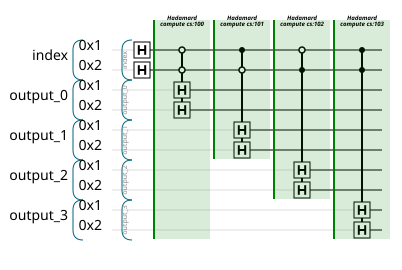

In [2]:
class Hadamard(Qubrick):
    """Apply a Hadamard gate to each qubit of the register."""
    def _compute(self, reg: Qubits, ctrl: Qubits):
        reg.had(cond=ctrl)

b_of_p = 2
num_items = 4

# Calculate the number of required qubits
num_index = int(np.ceil(np.log2(num_items)))
num_qubits = num_items * b_of_p + num_index

qpu = QPU(num_qubits=num_qubits)
index = Qubits(num_index, 'index', qpu)
output = vector_register(qpu, 'output', [b_of_p] * num_items, dtype='quint')

# Prepare a superposition of all possible indices in the index register
index.had()

# Instantiate Hadamard Qubrick and call its compute method for each subregister
usp = Hadamard(allow_multi_qubit_ctrl=True)
for ind in range(num_items):
    usp.compute(output[ind], ctrl=(index == ind))

qpu.print_state_vector()
state_naive = qpu.pull_state()
qpu.draw(show_qubricks=True)

In the example above, we used the `Hadamard` Qubrick to keep the circuits easy to read. However, in practical scenarios the unitary we want to inject can be arbitrarily complex! In this case, applying a separate unitary to each subregister is _incredibly_ wasteful.

Really, you just need to apply one unitary, as long as you have some mechanism to apply it on _each_ subregister at the same time.

## Enter SwapUp

As you may have guessed, this is _precisely_ what $\text{SwapUp}$ will do for us in this scenario.

Assuming a list of $n$ subregisters, this routine "swaps up" item with index $x$ from the loaded items to the top position, i.e., to the subregister with index $0$. The other items remain in positions $1, ..., n - 1$, possibly permuted in some order.

$$\ket{x}\ket{\vec{a}} \rightarrow \ket{x}\ket{a_x}\ket{\text{other elements in } \vec{a}}$$

> You can find a detailed example of using $\text{SwapUp}$ in the [data loading tutorial](Data_Loaders_QROM.ipynb#swapup).

How does $\text{SwapUp}$ help us inject a unitary using just one call to that unitary? We'll use the following workflow:

1. Use $\text{SwapUp}$ to bring $x^{th}$ subregister to the top of the vector register:
   $$\ket{x}\ket{\vec{a}} \rightarrow \ket{x}\ket{a_x}\ket{\text{other elements in } \vec{a}}$$

2. Apply the desired unitary $U$ to the top subregister:
   $$\rightarrow \ket{x} U\ket{a_x} \ket{\text{other elements in } \vec{a}}$$

3. Swap the subregisters back into place (that is, _uncompute_ $\text{SwapUp}$):
   $$\rightarrow \ket{x} \big( \ket{a_0} ... \ket{a_{x-1}} U\ket{a_x} \ket{a_{x+1}} ... \ket{a_{n-1}} \big)$$


## InjectOp

The $\text{InjectOp}$ operation ([`InjectOp`](https://construct.psiquantum.com/docs/psiqdk-algorithms/autoapi/psiqdk/algorithms/index.html#psiqdk.algorithms.InjectOp) Qubrick) implements the workflow described above as a single subroutine. $\text{InjectOp}$ implements the transformation defined in Eq. 9 in "Exponentially faster implementations of Select(H) for fermionic Hamiltonians" ([arXiv:2004.04170](https://arxiv.org/abs/2004.04170)).

The following code shows how to use `InjectOp` to inject the same unitary into a circuit using just one call to the `Hadamard` Qubrick.

|index|output_0|output_1|output_2|output_3>
|0|0|0|0|0>    0.250000+0.000000j
|0|1|0|0|0>    0.250000+0.000000j
|0|2|0|0|0>    0.250000+0.000000j
|0|3|0|0|0>    0.250000+0.000000j
|1|0|0|0|0>    0.250000+0.000000j
|1|0|1|0|0>    0.250000+0.000000j
|1|0|2|0|0>    0.250000+0.000000j
|1|0|3|0|0>    0.250000+0.000000j
|2|0|0|0|0>    0.250000+0.000000j
|2|0|0|1|0>    0.250000+0.000000j
|2|0|0|2|0>    0.250000+0.000000j
|2|0|0|3|0>    0.250000+0.000000j
|3|0|0|0|0>    0.250000+0.000000j
|3|0|0|0|1>    0.250000+0.000000j
|3|0|0|0|2>    0.250000+0.000000j
|3|0|0|0|3>    0.250000+0.000000j


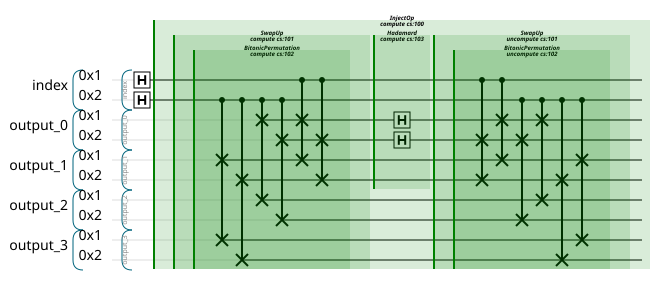

In [3]:
qpu = QPU(num_qubits=num_qubits)
index = Qubits(num_index, 'index', qpu)
output = vector_register(qpu, 'output', [b_of_p] * num_items, dtype='quint')

# Prepare a superposition of all possible indices in the index register
index.had()

# Instantiate Hadamard and InjectOp Qubricks
usp = Hadamard()
inject = InjectOp(SwapUp(), usp)
inject.compute(index, output, b_of_p)

qpu.print_state_vector()
state_injectop = qpu.pull_state()
qpu.draw(show_qubricks=True)

Now we can compare the two states prepared by the naive unitary injection and the `InjectOp` Qubrick to check that they are the same:

In [4]:
assert fidelity(state_naive, state_injectop) > 1 - 1E-6

## Summary

In this tutorial, we walked through injecting unitaries into a circuit.

- The naive approach requires multiple calls to controlled variant of the unitary, one per subregister we need to apply it to.
- $\text{InjectOp}$ Qubrick uses $\text{SwapUp}$ to do the same in a single call to the unitary.

Have fun injecting unitaries!